**MNIST HANDWRITTEN DIGIT CLASSIFICATION**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# opencv library (computer vision)
import cv2

# to show/display an image in colab itself
from google.colab.patches import cv2_imshow

# pillor for image processing tasks
from PIL import Image

# deep learning library

import tensorflow as tf

# set random seed (you can set any number)
tf.random.set_seed(3);

from tensorflow import keras

from keras.datasets import mnist

from tensorflow.math import confusion_matrix

**Loading the MNIIST data from keras.datasets**

In [3]:
# data collection part

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
type(X_train)

numpy.ndarray

In [5]:
#shape of the numpy arrays

# X_train has all images data and Y_train has all lables of corresponding images

print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape);

# 60k images and each has dimension 28x28 (it's gray scale that's why no 3rd dimension)
# if images are rgb instead of gray scale then we have 28x28x3 (rgb)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 60,000 images

Test data = 10,000 images

Image dimension ---> 28 x 28

Grayscale image --> 1 channel

In [6]:
#printing 69th image

print(X_train[68]);

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  29 170 255 255 141   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  29 198 255 255 255 226 255  86
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 141 255 255 170  29   0  86 255 255
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  29 226 255 198  57   0   0   0   0 226 255
  255 226 114   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  29 255 255 114   0   0   0   0   0   

In [7]:
print(X_train[10].shape)

(28, 28)


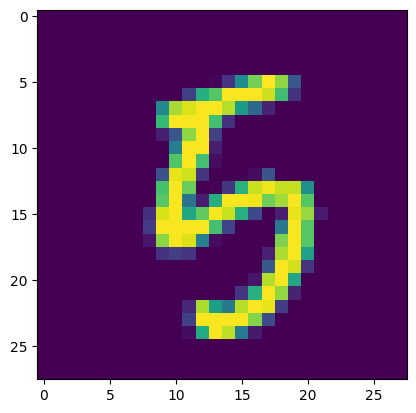

Corresponding lable is: 
5


In [8]:
#displaying the image

# imshow is used to show image

index = 690;
plt.imshow(X_train[index]);

plt.show();

# printing corresponding label as well

print("Corresponding lable is: ");
print(Y_train[index]);

# note but in reality images are gray scale not colored

**Image Lables**

In [9]:
print(Y_train.shape,Y_test.shape)

(60000,) (10000,)


In [10]:
#unique values in Y_train


print(np.unique(Y_train))


print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


We can use these labels as such or we can also apply one Hot Encoding

All the images have the same dimensions in this dataset, if not, we have to resize all the images to a common dimension

In [11]:
#scaling the values

#now normalize all the values (0 to 255) --> (0 to 1)

X_train = X_train/255.0;
X_test = X_test/255.0;


In [12]:
#printing 69th images

print(X_train[68])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the Neural Network

In [14]:
#setting up the layers of the neural network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)), # flattening the matrix (it will be input later)
    keras.layers.Dense(50,activation='relu'), #first parameter is no of neuron (it could be anything) (hidden layer 1)
    keras.layers.Dense(50,activation='relu'), #first parameter is no of neuron
    keras.layers.Dense(10,activation='sigmoid') #output layer (it should always 10 (because no of clases lable: 10))

]);


In [17]:
#compiling the Neural Network

model.compile(optimizer='adam', #adam optimizer
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'] #no of correct prediction/total no of data
              );


In [18]:
#training the neural network

model.fit(X_train,Y_train, epochs=10); #epochs means how many times our neural network should go through our data


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9135 - loss: 0.2996
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9594 - loss: 0.1376
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9705 - loss: 0.1011
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9763 - loss: 0.0801
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9799 - loss: 0.0658
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9834 - loss: 0.0546
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0464
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9877 - loss: 0.0399
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0359
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0312


Note above accuracy and loss is for training data.

Training data accuracy: 99%


**Accuracy on Test data**

In [19]:
loss, accuracy = model.evaluate(X_test,Y_test);

print("Loss: ",loss,"Accuracy: ",accuracy);

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.1039
Loss:  0.10388380289077759 Accuracy:  0.9728999733924866


Test data accuracy: 97.1%

In [20]:
print(X_test.shape); #10k images and each having dimension 28x28

(10000, 28, 28)


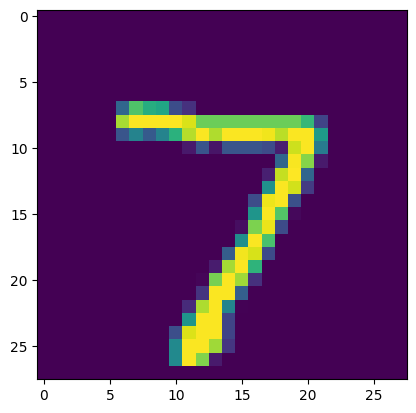

In [22]:
#first data point in X_test

plt.imshow(X_test[0]);
plt.show();

In [23]:
print(Y_test[0]);

7


In [24]:
Y_pred = model.predict(X_test);

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
print(Y_pred.shape)  #for each image 10 probabilities (0...9)

(10000, 10)


In [28]:
print(Y_pred[0]); #each value represent probability of each label


[5.3147326e-04 9.5099094e-06 2.4890872e-02 1.8675653e-02 5.1190571e-12
 1.2125437e-03 1.1413086e-15 9.9999708e-01 4.6352530e-04 9.8769766e-01]


model.predict() gives the prediction probability of each class for that data point

In [29]:
#converting the prediction probabilities to class label

label_for_first_image = np.argmax(Y_pred[0]); #it will return the index of maximum value

print(label_for_first_image);


7


In [31]:
#converting the predicition probabilities to class label for all test data points

Y_pred_labels = [np.argmax(i) for i in Y_pred] #means now it will do this for all test data

print(Y_pred_labels);

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test --> True Lables

Y_pred_labels --> predicted labels

Confusion Matrix

In [32]:
conf_matrix = confusion_matrix(Y_test,Y_pred_labels);

print(conf_matrix)

tf.Tensor(
[[ 962    1    3    0    0    0    3    0    3    8]
 [   1 1119    1    4    1    2    3    0    4    0]
 [   1    0 1003    8    3    0    4    5    7    1]
 [   0    0    4  987    0    6    0    3    3    7]
 [   1    0    2    1  960    2    6    0    1    9]
 [   3    0    1   12    1  861    4    1    6    3]
 [   3    2    2    1    5    6  939    0    0    0]
 [   3    1    9    6    1    0    0  986    3   19]
 [   0    0    4   13    2    5    3    3  935    9]
 [   3    1    0    7   11    4    1    1    4  977]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

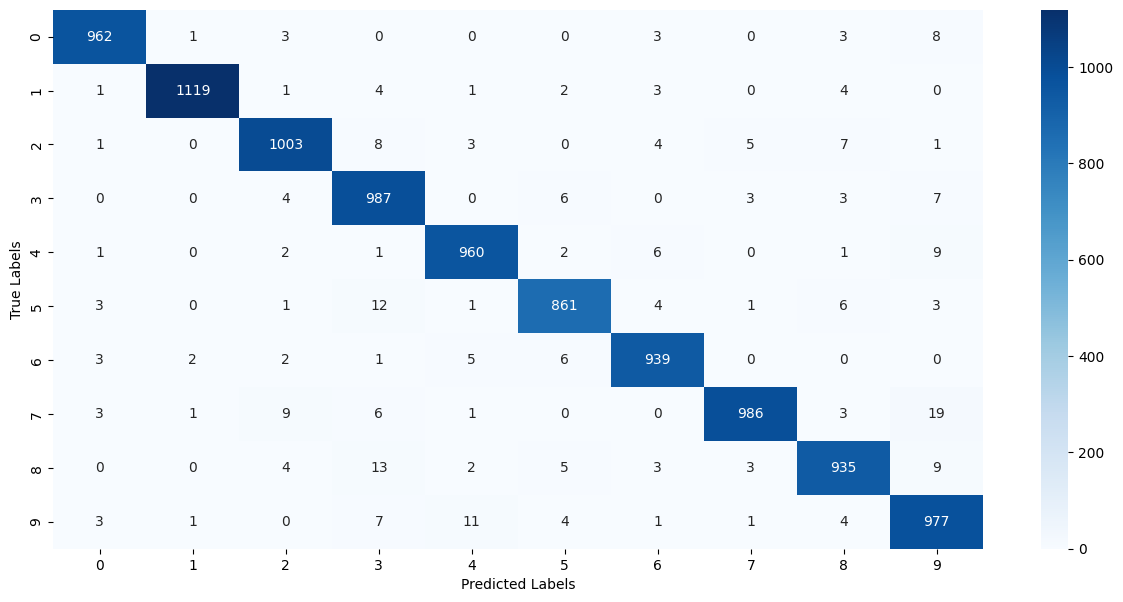

In [34]:
plt.figure(figsize=(15,7))

sns.heatmap(conf_matrix,annot=True, fmt='d',cmap='Blues');

plt.ylabel('True Labels');
plt.xlabel('Predicted Labels')

Building a Predictive System

In [85]:
input_image_path = '/content/mnist_7.webp';

input_image = cv2.imread(input_image_path); #image converted to numpy array


In [86]:
type(input_image)

numpy.ndarray

In [87]:
print(input_image)

[[[113 113 113]
  [ 70  70  70]
  [ 72  72  72]
  ...
  [ 72  72  72]
  [ 73  73  73]
  [188 188 188]]

 [[ 70  70  70]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  9   9   9]
  [171 171 171]]

 [[ 72  72  72]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  9   9   9]
  [174 174 174]]

 ...

 [[ 72  72  72]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  9   9   9]
  [174 174 174]]

 [[ 72  72  72]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  9   9   9]
  [174 174 174]]

 [[ 72  72  72]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  9   9   9]
  [173 173 173]]]


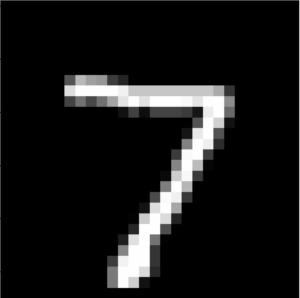

None


In [88]:
print(cv2_imshow(input_image))

In [89]:
print(input_image.shape)

(298, 300, 3)


In [90]:
#we don't want tgb image (because we trained on grayscale image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [91]:
grayscale.shape #now only 2 dimension

(298, 300)

In [92]:
#now let's resize the image

input_image_resize = cv2.resize(grayscale,(28,28))


In [93]:
print(input_image_resize.shape);

print(cv2_imshow(input_image_resize));


(28, 28)


None


In [94]:
#Now scaled this image

input_image_resize = input_image_resize/255.0

type(input_image_resize)

print(cv2_imshow(input_image_resize));

None


In [95]:
image_reshape = np.reshape(input_image_resize,[1,28,28]); #why this i am telling there is only 1 image

#above means i am going to predict for one image and that image has 28x28 dimension


In [96]:
input_prediction = model.predict(image_reshape);

print(input_prediction); #it will give probability value

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[5.3430325e-04 9.5281566e-06 2.5007475e-02 1.8674549e-02 5.1547317e-12
  1.2079218e-03 1.1560358e-15 9.9999702e-01 4.6694907e-04 9.8761791e-01]]


In [97]:
input_pred_label = np.argmax(input_prediction);

In [98]:
print(input_pred_label);

7


**Predictive System**

Path of the image to be predicted: /content/mnist_7.webp


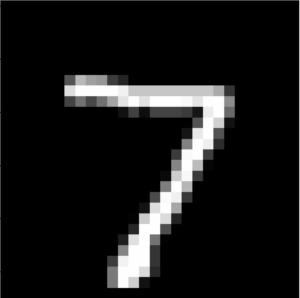

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
The Handwritten Digit is recognised as:  7
7


In [102]:
input_image_path = input('Path of the image to be predicted: ');

input_image = cv2.imread(input_image_path);

cv2_imshow(input_image);

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale,(28,28))

image_reshape = np.reshape(input_image_resize,[1,28,28]); #why this i am telling there is only 1 image

input_prediction = model.predict(image_reshape);

input_pred_label = np.argmax(input_prediction);


print("The Handwritten Digit is recognised as: ", input_pred_label);
print(input_pred_label);
